In [85]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split



In [86]:
data = {
    'Electronics_Spend': [900, 850, 200, 150],
    'Clothing_Spend': [200, 250, 800, 750],
    'Grocery_Spend': [100, 150, 300, 250],
    'Product': ['Laptop', 'Laptop', 'Jacket', 'Jacket']
}


In [87]:
df = pd.DataFrame(data)

In [88]:
X = df[['Electronics_Spend', 'Clothing_Spend', 'Grocery_Spend']]
y = df['Product']

In [89]:
le = LabelEncoder()
y = le.fit_transform(y)

In [90]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=1)

In [91]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [92]:
y_pred = knn.predict(X_test)

In [93]:
print("Predicted:", y_pred)


Predicted: [1]


In [94]:
df.isnull().sum()

Electronics_Spend    0
Clothing_Spend       0
Grocery_Spend        0
Product              0
dtype: int64

In [95]:
df = df.dropna(subset=["Product"])


In [96]:
df.isnull().sum()

Electronics_Spend    0
Clothing_Spend       0
Grocery_Spend        0
Product              0
dtype: int64

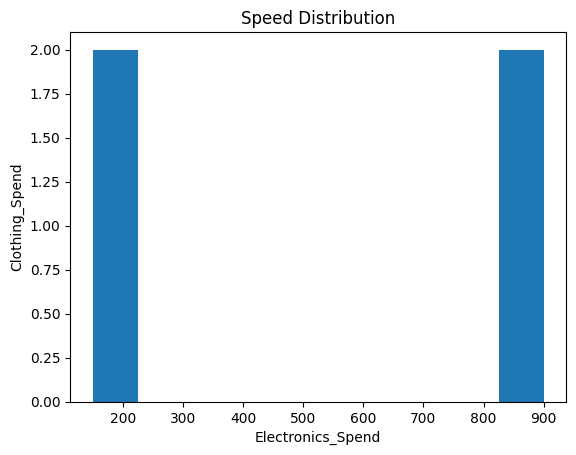

In [97]:
plt.hist(df["Electronics_Spend"], bins=10)
plt.xlabel("Electronics_Spend")
plt.ylabel("Clothing_Spend")
plt.title("Speed Distribution")
plt.show()

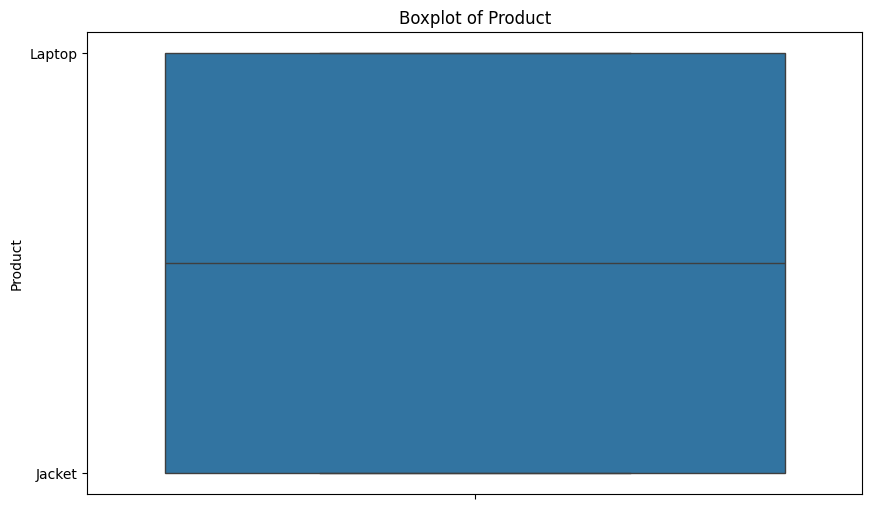

In [98]:
plt.figure(figsize=(10, 6))
sns.boxplot(y=df['Product'])
plt.title("Boxplot of Product")
plt.ylabel("Product")
plt.show()

In [99]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


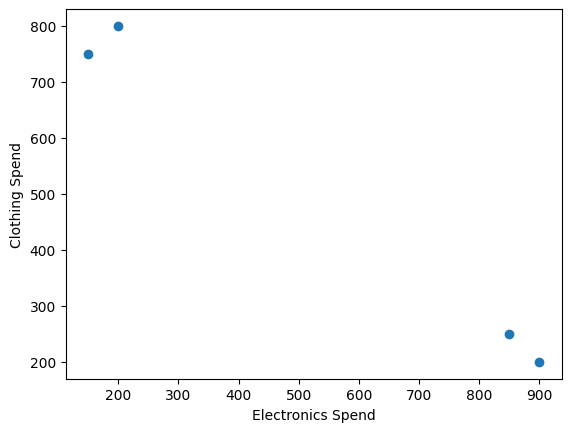

In [100]:
plt.scatter(df['Electronics_Spend'], df['Clothing_Spend'])
plt.xlabel("Electronics Spend")
plt.ylabel("Clothing Spend")
plt.show()

In [102]:
print("MAE :", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))



MAE : 0.0
RMSE: 0.0


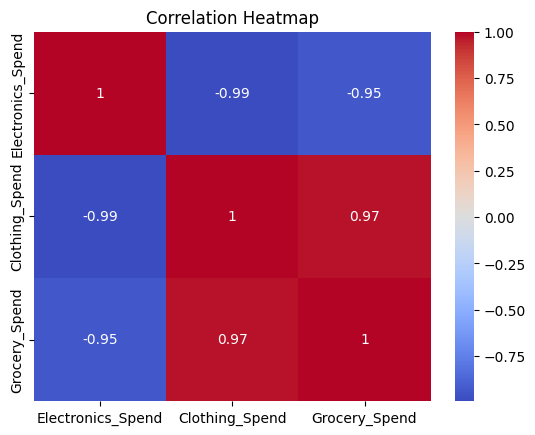

In [109]:
df.select_dtypes(include='number').corr()
sns.heatmap(df.select_dtypes(include='number').corr(),annot=True,cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [112]:
df.columns = df.columns.str.strip()

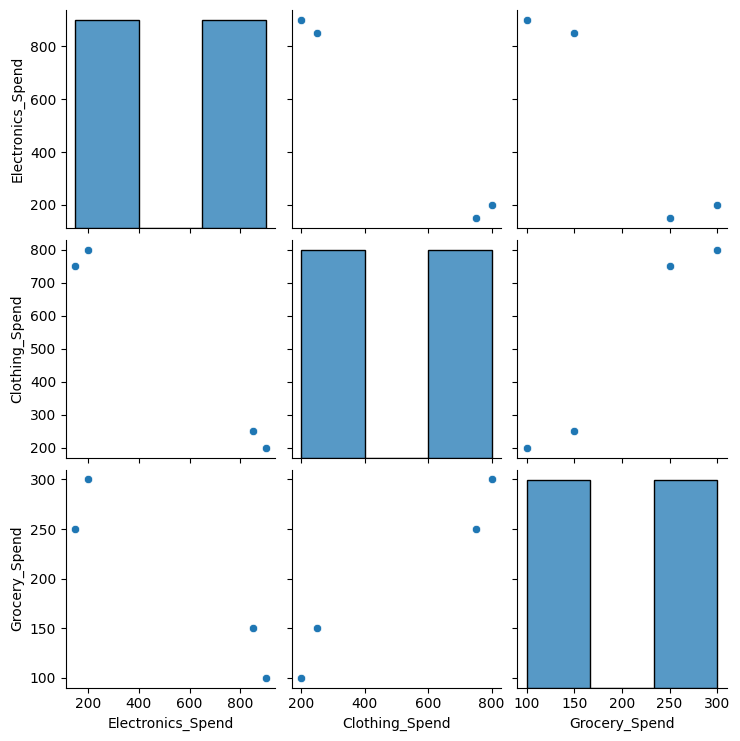

In [113]:
sns.pairplot(df[['Electronics_Spend','Clothing_Spend','Grocery_Spend','Product']])
plt.show()